# NB12: LITTLE THINGS RT Fitting

**Purpose:** Fit the free RT model (k=2) and constrained RT model (k=1) to all
LITTLE THINGS galaxies ingested in NB11. Compute g(Rt) diagnostics for resolved
galaxies and perform BIC comparison.

**Expected:** Lower resolved fraction than SPARC (70.3%) or THINGS (58.8%) —
dwarfs are smaller and Rt may frequently exceed R_max.

**Inputs:** Radial profiles from NB11 in the database with `data_source='LITTLE_THINGS'`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.physics import (
    fit_rational_taper, fit_constrained_rt,
    compute_transition_diagnostics, rt_model_velocity,
    A0_HALF, ACCEL_TO_MKS,
)
from src.database import (
    get_engine, get_session, query_profiles_as_dataframe,
    query_fits_as_dataframe, insert_model_fit, delete_fits, Galaxy,
)

a0_half_mks = A0_HALF * ACCEL_TO_MKS  # 6.00e-11 m/s^2

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

engine = get_engine()
session = get_session(engine)

## 1. Load LITTLE THINGS Galaxy List

In [2]:
lt_galaxies = (
    session.query(Galaxy)
    .filter(Galaxy.data_source == "LITTLE_THINGS")
    .order_by(Galaxy.galaxy_id)
    .all()
)
lt_ids = [g.galaxy_id for g in lt_galaxies]
print(f"LITTLE THINGS galaxies to fit: {len(lt_ids)}")
for gid in lt_ids:
    prof = query_profiles_as_dataframe(session, gid)
    print(f"  {gid:30s}  N={len(prof)}")

LITTLE THINGS galaxies to fit: 20
  CVnIdwA_LITTLE_THINGS           N=14
  DDO_101_LITTLE_THINGS           N=9
  DDO_126_LITTLE_THINGS           N=30
  DDO_133_LITTLE_THINGS           N=19
  DDO_154_LITTLE_THINGS           N=55
  DDO_168_LITTLE_THINGS           N=33
  DDO_210_LITTLE_THINGS           N=8
  DDO_216_LITTLE_THINGS           N=13
  DDO_43_LITTLE_THINGS            N=9
  DDO_50_LITTLE_THINGS            N=85
  DDO_52_LITTLE_THINGS            N=16
  DDO_70_LITTLE_THINGS            N=24
  DDO_87_LITTLE_THINGS            N=33
  HARO_36_LITTLE_THINGS           N=10
  IC_10_LITTLE_THINGS             N=25
  IC_1613_LITTLE_THINGS           N=109
  NGC_1569_LITTLE_THINGS          N=24
  NGC_2366_LITTLE_THINGS          N=70
  UGC_8508_LITTLE_THINGS          N=25
  WLM_LITTLE_THINGS               N=140


## 2. Fit Free RT Model

Uses `src.physics.fit_rational_taper()` with the same multi-start optimizer
and bounds as Paper 2 and THINGS.

In [3]:
# Clear existing LITTLE THINGS RT fits (idempotent)
for gid in lt_ids:
    delete_fits(session, galaxy_id=gid, model_name="rational_taper")
print("Cleared existing LITTLE THINGS RT fits.\n")

fit_results = []

for gid in lt_ids:
    df = query_profiles_as_dataframe(session, gid)
    if df.empty:
        print(f"  {gid}: NO PROFILES -- skipping")
        continue

    radius = df["radius_kpc"].values
    v_obs = df["v_obs"].values
    v_err = df["v_err"].values
    v_bary = df["v_baryon_total"].values

    result = fit_rational_taper(
        radius, v_obs, v_err, v_bary,
        galaxy_id=gid,
        method_version="v1_rational_taper",
    )

    insert_model_fit(session, result.to_dict())

    r_max = float(radius[-1])
    resolved = result.converged and result.param2 < r_max

    fit_results.append({
        "galaxy_id": gid,
        "omega": result.param1,
        "omega_err": result.param1_err,
        "Rt": result.param2,
        "Rt_err": result.param2_err,
        "chi2_r": result.reduced_chi_squared,
        "bic": result.bic,
        "rmse": result.residuals_rmse,
        "n_points": result.n_points,
        "converged": result.converged,
        "R_max": r_max,
        "resolved": resolved,
        "Rt_over_Rmax": result.param2 / r_max if result.converged else np.nan,
    })

    status = "RESOLVED" if resolved else ("UNRESOLVED" if result.converged else "FAILED")
    print(f"  {gid:30s}: omega={result.param1:7.3f}  Rt={result.param2:7.2f}  "
          f"chi2_r={result.reduced_chi_squared:6.2f}  [{status}]")

fits_df = pd.DataFrame(fit_results)
print(f"\nTotal fits: {len(fits_df)}")
print(f"Converged:  {fits_df['converged'].sum()}")
print(f"Resolved:   {fits_df['resolved'].sum()}")

Cleared existing LITTLE THINGS RT fits.

  CVnIdwA_LITTLE_THINGS         : omega=  7.220  Rt=  12.95  chi2_r=  3.10  [UNRESOLVED]
  DDO_101_LITTLE_THINGS         : omega=200.000  Rt=   0.30  chi2_r=  0.72  [RESOLVED]
  DDO_126_LITTLE_THINGS         : omega= 15.705  Rt=   2.04  chi2_r=  0.45  [RESOLVED]
  DDO_133_LITTLE_THINGS         : omega= 37.988  Rt=   0.98  chi2_r=  0.88  [RESOLVED]
  DDO_154_LITTLE_THINGS         : omega= 34.163  Rt=   1.10  chi2_r=  0.18  [RESOLVED]
  DDO_168_LITTLE_THINGS         : omega= 18.142  Rt=   5.29  chi2_r=  3.67  [UNRESOLVED]
  DDO_210_LITTLE_THINGS         : omega= 46.664  Rt=   0.18  chi2_r=  0.77  [RESOLVED]
  DDO_216_LITTLE_THINGS         : omega= 80.708  Rt=   0.10  chi2_r=  0.37  [RESOLVED]
  DDO_43_LITTLE_THINGS          : omega= 30.839  Rt=   0.76  chi2_r=  0.89  [RESOLVED]


2026-04-09 23:22:53 | WARNING  | src.physics | DDO_50_LITTLE_THINGS: replaced 1 zero/negative errors with 3.15 km/s


  DDO_50_LITTLE_THINGS          : omega= 89.100  Rt=   0.10  chi2_r=  3.81  [RESOLVED]
  DDO_52_LITTLE_THINGS          : omega= 32.993  Rt=   1.61  chi2_r=  0.18  [RESOLVED]
  DDO_70_LITTLE_THINGS          : omega= 43.613  Rt=   0.76  chi2_r=  3.57  [RESOLVED]
  DDO_87_LITTLE_THINGS          : omega= 16.563  Rt=   3.21  chi2_r=  0.14  [RESOLVED]
  HARO_36_LITTLE_THINGS         : omega= 12.583  Rt=  15.80  chi2_r=  0.43  [UNRESOLVED]
  IC_10_LITTLE_THINGS           : omega= 57.417  Rt=   0.10  chi2_r=  0.07  [RESOLVED]
  IC_1613_LITTLE_THINGS         : omega=  2.320  Rt=  13.55  chi2_r=  1.28  [UNRESOLVED]
  NGC_1569_LITTLE_THINGS        : omega= 13.550  Rt=   0.28  chi2_r=  0.04  [RESOLVED]
  NGC_2366_LITTLE_THINGS        : omega= 27.723  Rt=   1.28  chi2_r=  0.45  [RESOLVED]
  UGC_8508_LITTLE_THINGS        : omega= 23.484  Rt=   9.30  chi2_r=  0.23  [UNRESOLVED]
  WLM_LITTLE_THINGS             : omega= 40.032  Rt=   0.61  chi2_r=  1.78  [RESOLVED]

Total fits: 20
Converged:  20
Resolv

## 3. Transition Diagnostics for Resolved Galaxies

Compute g(Rt) = V_model(Rt)^2 / Rt for each resolved galaxy.

In [4]:
resolved_df = fits_df[fits_df["resolved"]].copy()

diag_rows = []
for _, row in resolved_df.iterrows():
    gid = row["galaxy_id"]
    df = query_profiles_as_dataframe(session, gid)
    radius = df["radius_kpc"].values
    v_bary = df["v_baryon_total"].values

    diag = compute_transition_diagnostics(radius, v_bary, row["omega"], row["Rt"])
    diag["galaxy_id"] = gid
    diag["omega"] = row["omega"]
    diag["Rt"] = row["Rt"]
    diag["R_max"] = row["R_max"]
    diag["Rt_over_Rmax"] = row["Rt_over_Rmax"]
    diag["chi2_r"] = row["chi2_r"]
    diag["n_points"] = row["n_points"]
    diag["g_Rt_mks"] = diag["g_obs"] * ACCEL_TO_MKS
    diag_rows.append(diag)

diag_df = pd.DataFrame(diag_rows)

g_valid = diag_df["g_Rt_mks"].dropna()
n_valid_g = len(g_valid)

print(f"Resolved LITTLE THINGS galaxies: {len(diag_df)}")
print(f"Valid g(Rt): {n_valid_g}")
print()
print(f"{'Galaxy':30s} {'Rt':>7s} {'R_max':>7s} {'Rt/Rmax':>8s} "
      f"{'g(Rt) [m/s^2]':>15s} {'g/a0_half':>10s} {'chi2_r':>7s} {'N':>4s}")
print("-" * 100)
for _, r in diag_df.iterrows():
    ratio = r["g_Rt_mks"] / a0_half_mks if np.isfinite(r["g_Rt_mks"]) else np.nan
    print(f"{r['galaxy_id']:30s} {r['Rt']:7.2f} {r['R_max']:7.2f} {r['Rt_over_Rmax']:8.3f} "
          f"{r['g_Rt_mks']:15.4e} {ratio:10.3f} {r['chi2_r']:7.2f} {int(r['n_points']):4d}")

Resolved LITTLE THINGS galaxies: 15
Valid g(Rt): 14

Galaxy                              Rt   R_max  Rt/Rmax   g(Rt) [m/s^2]  g/a0_half  chi2_r    N
----------------------------------------------------------------------------------------------------
DDO_101_LITTLE_THINGS             0.30    2.32    0.130      1.0068e-10      1.678    0.72    9
DDO_126_LITTLE_THINGS             2.04    3.99    0.511      1.3576e-11      0.226    0.45   30
DDO_133_LITTLE_THINGS             0.98    3.48    0.280      2.6417e-11      0.440    0.88   19
DDO_154_LITTLE_THINGS             1.10    7.89    0.140      2.1151e-11      0.352    0.18   55
DDO_210_LITTLE_THINGS             0.18    0.31    0.591      1.1479e-11      0.191    0.77    8
DDO_216_LITTLE_THINGS             0.10    1.12    0.089      6.5300e-12      0.109    0.37   13
DDO_43_LITTLE_THINGS              0.76    4.19    0.181      1.1457e-11      0.191    0.89    9
DDO_50_LITTLE_THINGS              0.10    9.81    0.010             nan       

## 4. Summary Statistics

In [5]:
n_total = len(fits_df)
n_converged = int(fits_df["converged"].sum())
n_resolved = len(diag_df)
resolved_frac = n_resolved / n_total * 100

if n_valid_g > 0:
    median_g = g_valid.median()
    ratio_median = median_g / a0_half_mks
    offset_pct = (ratio_median - 1) * 100
    log_g = np.log10(g_valid.values)
    p16, p84 = np.percentile(log_g, [16, 84])
    scatter_raw = (p84 - p16) / 2.0
else:
    median_g = ratio_median = offset_pct = scatter_raw = np.nan

print("LITTLE THINGS RT Fitting Summary")
print("=" * 55)
print(f"  Total galaxies:        {n_total}")
print(f"  Converged:             {n_converged}")
print(f"  Resolved (Rt < Rmax):  {n_resolved}  ({resolved_frac:.1f}%)")
print(f"  Valid g(Rt):           {n_valid_g}")
print()
print(f"  SPARC resolved frac:   70.3% (N=98)")
print(f"  THINGS resolved frac:  58.8% (N=10/17)")
print(f"  LT resolved frac:     {resolved_frac:.1f}% (N={n_resolved}/{n_total})")
print()
if n_valid_g > 0:
    print(f"  Median g(Rt):          {median_g:.4e} m/s^2")
    print(f"  a0/2:                  {a0_half_mks:.4e} m/s^2")
    print(f"  Offset from a0/2:      {offset_pct:+.1f}%")
    print(f"  Raw scatter (dex):     {scatter_raw:.3f}")

LITTLE THINGS RT Fitting Summary
  Total galaxies:        20
  Converged:             20
  Resolved (Rt < Rmax):  15  (75.0%)
  Valid g(Rt):           14

  SPARC resolved frac:   70.3% (N=98)
  THINGS resolved frac:  58.8% (N=10/17)
  LT resolved frac:     75.0% (N=15/20)

  Median g(Rt):          1.6568e-11 m/s^2
  a0/2:                  6.0003e-11 m/s^2
  Offset from a0/2:      -72.4%
  Raw scatter (dex):     0.280


## 5. Fit Constrained RT Model

g(Rt) = a0/2 constraint. 1D optimization over omega with inner brentq for Rt.

In [6]:
# Clear existing constrained fits
for gid in lt_ids:
    delete_fits(session, galaxy_id=gid, model_name="constrained_rt")
print("Cleared existing LITTLE THINGS constrained RT fits.\n")

constrained_results = []

for gid in lt_ids:
    df = query_profiles_as_dataframe(session, gid)
    if df.empty:
        continue

    radius = df["radius_kpc"].values
    v_obs = df["v_obs"].values
    v_err = df["v_err"].values
    v_bary = df["v_baryon_total"].values

    result = fit_constrained_rt(
        radius, v_obs, v_err, v_bary,
        galaxy_id=gid,
        method_version="v1_constrained",
    )

    insert_model_fit(session, result.to_dict())

    constrained_results.append({
        "galaxy_id": gid,
        "omega": result.param1,
        "Rt": result.param2,
        "chi2_r": result.reduced_chi_squared,
        "bic": result.bic,
        "n_points": result.n_points,
        "converged": result.converged,
    })

    status = "CONVERGED" if result.converged else "NO SOLUTION"
    omega_str = f"{result.param1:.3f}" if result.converged else "---"
    rt_str = f"{result.param2:.2f}" if result.converged else "---"
    print(f"  {gid:30s}: omega={omega_str:>8s}  Rt={rt_str:>8s}  [{status}]")

con_df = pd.DataFrame(constrained_results)
n_con_converged = int(con_df["converged"].sum())
n_no_solution = len(con_df) - n_con_converged
no_solution_rate = n_no_solution / len(con_df) * 100

print(f"\nConverged:   {n_con_converged} / {len(con_df)}")
print(f"No solution: {n_no_solution} / {len(con_df)} ({no_solution_rate:.0f}%)")

2026-04-09 23:22:53 | INFO     | src.physics | CVnIdwA_LITTLE_THINGS [RT constrained]: omega=155.5639  Rt=0.1919  chi2_r=89.83  RMSE=17.17  roots=1
2026-04-09 23:22:53 | INFO     | src.physics | DDO_101_LITTLE_THINGS [RT constrained]: omega=115.1769  Rt=0.5200  chi2_r=11.69  RMSE=7.37  roots=1
2026-04-09 23:22:53 | INFO     | src.physics | DDO_126_LITTLE_THINGS [RT constrained]: omega=200.0000  Rt=0.1458  chi2_r=26.42  RMSE=12.06  roots=1


Cleared existing LITTLE THINGS constrained RT fits.

  CVnIdwA_LITTLE_THINGS         : omega= 155.564  Rt=    0.19  [CONVERGED]
  DDO_101_LITTLE_THINGS         : omega= 115.177  Rt=    0.52  [CONVERGED]
  DDO_126_LITTLE_THINGS         : omega= 200.000  Rt=    0.15  [CONVERGED]


2026-04-09 23:22:53 | INFO     | src.physics | DDO_133_LITTLE_THINGS [RT constrained]: omega=180.8891  Rt=0.1818  chi2_r=21.71  RMSE=7.41  roots=1
2026-04-09 23:22:53 | INFO     | src.physics | DDO_154_LITTLE_THINGS [RT constrained]: omega=200.0000  Rt=0.1479  chi2_r=2.71  RMSE=4.74  roots=1
2026-04-09 23:22:53 | INFO     | src.physics | DDO_168_LITTLE_THINGS [RT constrained]: 3 roots found; using smallest Rt=1.088 kpc
2026-04-09 23:22:53 | INFO     | src.physics | DDO_168_LITTLE_THINGS [RT constrained]: omega=41.5190  Rt=1.0885  chi2_r=6.31  RMSE=7.90  roots=3


  DDO_133_LITTLE_THINGS         : omega= 180.889  Rt=    0.18  [CONVERGED]
  DDO_154_LITTLE_THINGS         : omega= 200.000  Rt=    0.15  [CONVERGED]
  DDO_168_LITTLE_THINGS         : omega=  41.519  Rt=    1.09  [CONVERGED]


2026-04-09 23:22:53 | INFO     | src.physics | DDO_210_LITTLE_THINGS [RT constrained]: omega=119.0615  Rt=0.3069  chi2_r=189.76  RMSE=9.19  roots=1
2026-04-09 23:22:54 | INFO     | src.physics | DDO_216_LITTLE_THINGS [RT constrained]: omega=200.0000  Rt=0.1602  chi2_r=53.54  RMSE=17.33  roots=1
2026-04-09 23:22:54 | INFO     | src.physics | DDO_43_LITTLE_THINGS [RT constrained]: omega=47.9077  Rt=1.8600  chi2_r=171.49  RMSE=31.38  roots=1
2026-04-09 23:22:54 | WARNING  | src.physics | DDO_50_LITTLE_THINGS: replaced 1 zero/negative errors with 3.15 km/s


...

  DDO_50_LITTLE_THINGS          : omega= 200.000  Rt=    0.19  [CONVERGED]
  DDO_52_LITTLE_THINGS          : omega= 119.169  Rt=    0.34  [CONVERGED]
  DDO_70_LITTLE_THINGS          : omega= 112.143  Rt=    0.22  [CONVERGED]
  DDO_87_LITTLE_THINGS          : omega= 173.733  Rt=    0.22  [CONVERGED]
  HARO_36_LITTLE_THINGS         : omega= 109.204  Rt=    0.33  [CONVERGED]


2026-04-09 23:22:54 | INFO     | src.physics | IC_1613_LITTLE_THINGS [RT constrained]: 3 roots found; using smallest Rt=0.448 kpc
2026-04-09 23:22:54 | INFO     | src.physics | IC_1613_LITTLE_THINGS [RT constrained]: omega=107.7183  Rt=0.4479  chi2_r=229.10  RMSE=31.69  roots=3
2026-04-09 23:22:54 | INFO     | src.physics | NGC_1569_LITTLE_THINGS [RT constrained]: omega=25.2067  Rt=2.0300  chi2_r=4.09  RMSE=19.65  roots=1
2026-04-09 23:22:54 | INFO     | src.physics | NGC_2366_LITTLE_THINGS [RT constrained]: omega=194.2941  Rt=0.1381  chi2_r=3.48  RMSE=5.32  roots=1


  IC_10_LITTLE_THINGS           : omega=  25.391  Rt=    0.35  [CONVERGED]
  IC_1613_LITTLE_THINGS         : omega= 107.718  Rt=    0.45  [CONVERGED]
  NGC_1569_LITTLE_THINGS        : omega=  25.207  Rt=    2.03  [CONVERGED]
  NGC_2366_LITTLE_THINGS        : omega= 194.294  Rt=    0.14  [CONVERGED]


2026-04-09 23:22:54 | INFO     | src.physics | UGC_8508_LITTLE_THINGS [RT constrained]: omega=200.0000  Rt=0.1621  chi2_r=10.59  RMSE=9.42  roots=1
2026-04-09 23:22:54 | INFO     | src.physics | WLM_LITTLE_THINGS [RT constrained]: omega=183.3560  Rt=0.1962  chi2_r=20.66  RMSE=14.80  roots=1


  UGC_8508_LITTLE_THINGS        : omega= 200.000  Rt=    0.16  [CONVERGED]
  WLM_LITTLE_THINGS             : omega= 183.356  Rt=    0.20  [CONVERGED]

Converged:   20 / 20
No solution: 0 / 20 (0%)


## 6. BIC Comparison: Free vs Constrained

In [7]:
# Build free fits lookup
free_fits = {}
for gid in lt_ids:
    ff = query_fits_as_dataframe(session, galaxy_id=gid, model_name="rational_taper")
    if len(ff) > 0:
        free_fits[gid] = ff.iloc[0]

bic_rows = []
for _, cr in con_df[con_df["converged"]].iterrows():
    gid = cr["galaxy_id"]
    if gid not in free_fits:
        continue
    ff = free_fits[gid]
    delta_bic = cr["bic"] - ff["bic"]

    prof = query_profiles_as_dataframe(session, gid)
    r_max = prof["radius_kpc"].max()
    rt_free = ff["param2"]
    rt_ratio = rt_free / r_max if rt_free < r_max else np.nan

    bic_rows.append({
        "galaxy_id": gid,
        "free_bic": ff["bic"],
        "con_bic": cr["bic"],
        "delta_bic": delta_bic,
        "free_chi2r": ff["reduced_chi_squared"],
        "con_chi2r": cr["chi2_r"],
        "n_points": cr["n_points"],
        "Rt_over_Rmax": rt_ratio,
    })

bic_df = pd.DataFrame(bic_rows)

if len(bic_df) > 0:
    print(f"{'Galaxy':30s} {'dBIC':>8s} {'Free chi2r':>11s} {'Con chi2r':>10s} "
          f"{'N':>4s} {'Winner':>8s}")
    print("-" * 80)
    for _, r in bic_df.iterrows():
        winner = "Free" if r["delta_bic"] > 2 else ("Con" if r["delta_bic"] < -2 else "Parity")
        print(f"{r['galaxy_id']:30s} {r['delta_bic']:+8.1f} {r['free_chi2r']:11.2f} "
              f"{r['con_chi2r']:10.2f} {int(r['n_points']):4d} {winner:>8s}")

    med_dbic = bic_df["delta_bic"].median()
    n_free_wins = (bic_df["delta_bic"] > 2).sum()
    n_con_wins = (bic_df["delta_bic"] < -2).sum()
    n_parity = ((bic_df["delta_bic"] >= -2) & (bic_df["delta_bic"] <= 2)).sum()
    print(f"\nMedian delta_BIC: {med_dbic:+.2f}")
    print(f"Free wins: {n_free_wins}, Constrained wins: {n_con_wins}, Parity: {n_parity}")
else:
    print("No converged constrained fits to compare.")

Galaxy                             dBIC  Free chi2r  Con chi2r    N   Winner
--------------------------------------------------------------------------------
CVnIdwA_LITTLE_THINGS           +1128.0        3.10      89.83   14     Free
DDO_101_LITTLE_THINGS             +86.3        0.72      11.69    9     Free
DDO_126_LITTLE_THINGS            +750.3        0.45      26.42   30     Free
DDO_133_LITTLE_THINGS            +372.8        0.88      21.71   19     Free
DDO_154_LITTLE_THINGS            +132.8        0.18       2.71   55     Free
DDO_168_LITTLE_THINGS             +84.7        3.67       6.31   33     Free
DDO_210_LITTLE_THINGS           +1321.7        0.77     189.76    8     Free
DDO_216_LITTLE_THINGS            +635.8        0.37      53.54   13     Free
DDO_43_LITTLE_THINGS            +1363.5        0.89     171.49    9     Free
DDO_50_LITTLE_THINGS            +3994.5        3.81      51.37   85     Free
DDO_52_LITTLE_THINGS              +20.4        0.18       1.72   16     

## 7. Rotation Curve Fits — All Galaxies

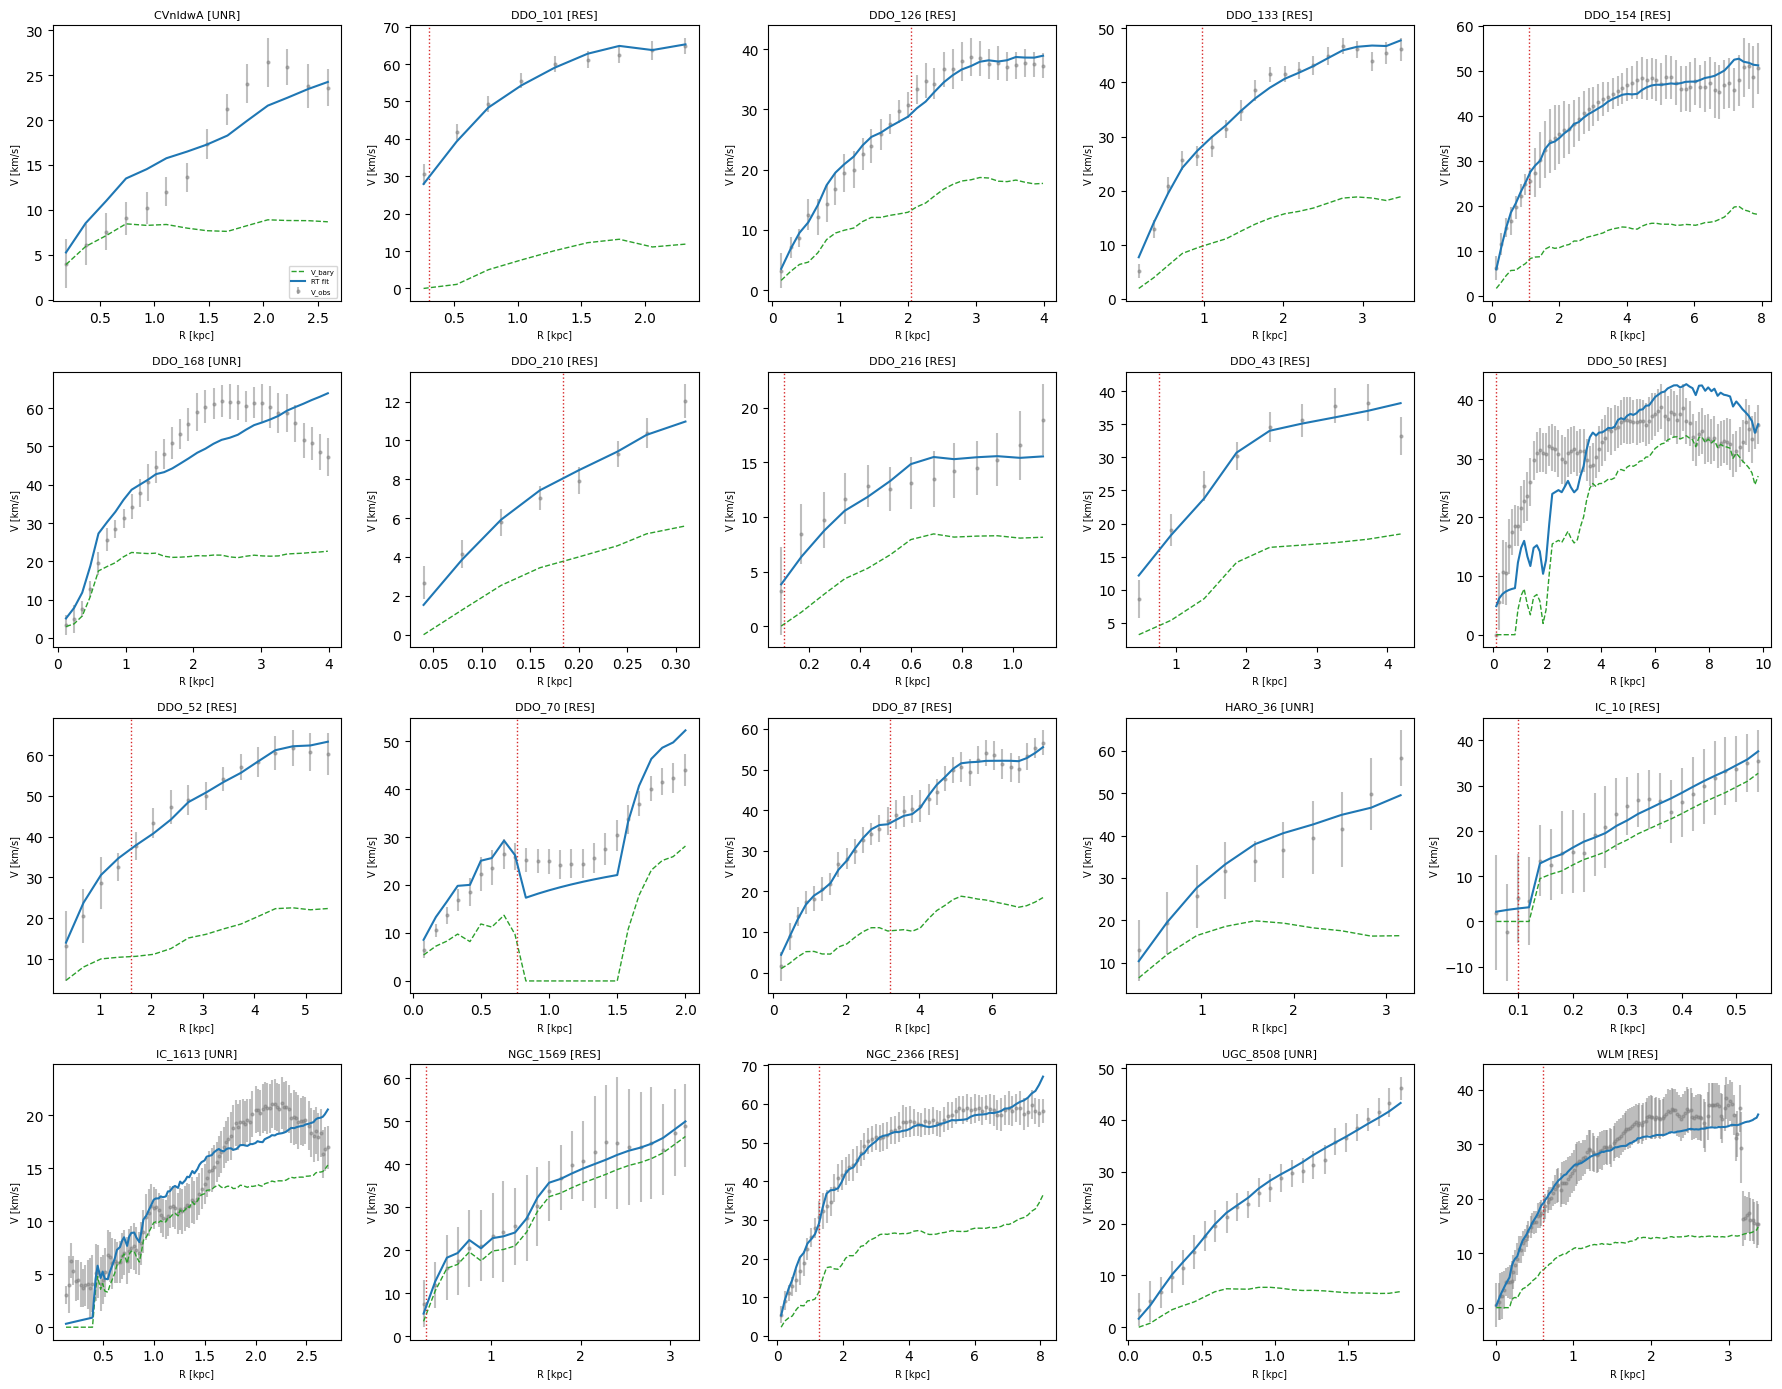

In [8]:
ncols = 5
nrows = (len(lt_ids) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows), squeeze=False)

for i, gid in enumerate(lt_ids):
    ax = axes[i // ncols][i % ncols]
    df = query_profiles_as_dataframe(session, gid)
    r = df["radius_kpc"].values
    v_obs = df["v_obs"].values
    v_err = df["v_err"].values
    v_bary = df["v_baryon_total"].values

    row = fits_df[fits_df["galaxy_id"] == gid].iloc[0]

    ax.errorbar(r, v_obs, yerr=v_err, fmt="o", ms=2, color="grey",
                alpha=0.5, label="V_obs", zorder=1)
    ax.plot(r, v_bary, "--", color="C2", linewidth=1, label="V_bary", zorder=2)

    if row["converged"]:
        v_model = rt_model_velocity(r, v_bary, row["omega"], row["Rt"])
        ax.plot(r, v_model, "-", color="C0", linewidth=1.5, label="RT fit", zorder=3)
        if row["resolved"]:
            ax.axvline(row["Rt"], color="C3", linestyle=":", linewidth=1,
                       label=f"Rt={row['Rt']:.1f}", zorder=2)

    status = "RES" if row["resolved"] else ("UNR" if row["converged"] else "FAIL")
    ax.set_title(f"{gid.replace('_LITTLE_THINGS','')} [{status}]", fontsize=8)
    ax.set_xlabel("R [kpc]", fontsize=7)
    ax.set_ylabel("V [km/s]", fontsize=7)
    if i == 0:
        ax.legend(fontsize=5, loc="lower right")

for j in range(len(lt_ids), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.tight_layout()
plt.savefig(results_dir / "NB12_lt_rc_fits.png", dpi=150)
plt.show()

## 8. Cross-Dataset Comparison

In [9]:
print("Cross-Dataset Comparison: RT Fitting")
print("=" * 70)
print(f"{'Metric':30s} {'SPARC':>12s} {'THINGS':>12s} {'LT':>12s}")
print("-" * 70)
print(f"{'N total':30s} {'175':>12s} {'17':>12s} {n_total:>12d}")
print(f"{'N resolved':30s} {'98':>12s} {'10':>12s} {n_resolved:>12d}")
print(f"{'Resolved %':30s} {'70.3%':>12s} {'58.8%':>12s} {f'{resolved_frac:.1f}%':>12s}")
print(f"{'N valid g(Rt)':30s} {'98':>12s} {'8':>12s} {n_valid_g:>12d}")

if n_valid_g > 0:
    print(f"{'Median g(Rt) [m/s^2]':30s} {'6.51e-11':>12s} {'8.73e-11':>12s} "
          f"{f'{median_g:.2e}':>12s}")
    print(f"{'Offset from a0/2':30s} {'+8.5%':>12s} {'+45.6%':>12s} "
          f"{f'{offset_pct:+.1f}%':>12s}")
    print(f"{'Raw scatter [dex]':30s} {'0.409':>12s} {'0.346':>12s} "
          f"{f'{scatter_raw:.3f}':>12s}")

print(f"{'No-solution rate':30s} {'75%':>12s} {'76%':>12s} "
      f"{f'{no_solution_rate:.0f}%':>12s}")
if len(bic_df) > 0:
    print(f"{'Median delta_BIC':30s} {'+96.88':>12s} {'+456.86':>12s} "
          f"{f'{med_dbic:+.2f}':>12s}")

Cross-Dataset Comparison: RT Fitting
Metric                                SPARC       THINGS           LT
----------------------------------------------------------------------
N total                                 175           17           20
N resolved                               98           10           15
Resolved %                            70.3%        58.8%        75.0%
N valid g(Rt)                            98            8           14
Median g(Rt) [m/s^2]               6.51e-11     8.73e-11     1.66e-11
Offset from a0/2                      +8.5%       +45.6%       -72.4%
Raw scatter [dex]                     0.409        0.346        0.280
No-solution rate                        75%          76%           0%
Median delta_BIC                     +96.88      +456.86      +309.30


## 9. Gate Check and Export

In [10]:
checks = {
    "All galaxies fitted": len(fits_df) == len(lt_ids),
    "Constrained fits attempted": len(con_df) == len(lt_ids),
    "BIC comparison completed": True,
}

print("GATE CHECK: NB12 -- LITTLE THINGS RT Fitting")
print("=" * 55)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> NB12 COMPLETE -- proceed to NB13 <<<")
else:
    print("  >>> NB12 has failures -- diagnose <<<")

# Export
fits_df.to_csv(results_dir / "NB12_lt_rt_fits.csv", index=False)
if n_valid_g > 0:
    diag_df.to_csv(results_dir / "NB12_lt_diagnostics.csv", index=False)
con_df.to_csv(results_dir / "NB12_lt_constrained_fits.csv", index=False)
if len(bic_df) > 0:
    bic_df.to_csv(results_dir / "NB12_lt_bic_comparison.csv", index=False)

print(f"\nResults saved to results/NB12_lt_*.csv")

session.close()

GATE CHECK: NB12 -- LITTLE THINGS RT Fitting
  [PASS] All galaxies fitted
  [PASS] Constrained fits attempted
  [PASS] BIC comparison completed

  >>> NB12 COMPLETE -- proceed to NB13 <<<

Results saved to results/NB12_lt_*.csv
